In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from mini_nn import Sequential
from mini_nn.layers import Linear, ReLu
from mini_nn.losses import MSELoss
from mini_nn.optim import SGD
from sklearn.model_selection import train_test_split

In [2]:
# --- Generate Data (uses the same data as '01_end_to_end_regression_training')
# --- set generator ---
gen = np.random.default_rng(42)

# --- create features ---
n = 10_000

x1 = np.arange(0, 1, 0.0001)
x2 = gen.uniform(0, 1, n)
x3 = gen.uniform(0.001, 5, n)

noise = gen.uniform(-1, 1, n)
constant = 0.5

# --- merge x and create y ---
x = np.column_stack([x1, x2, x3])

y = (
    3 * x1
    - 2 * (x2 ** x1)
    + np.log(x3)
    + constant
    + noise
)

y = y.reshape(-1, 1)

print(f'x shape: {x.shape}')
print(f'y shape: {y.shape}')

x shape: (10000, 3)
y shape: (10000, 1)


In [3]:
x_train, x_test, y_train, y_test = train_test_split(x, y, 
                                                    random_state=42)

In [9]:
# --- Build a model ---
model = Sequential([
    Linear(x_train.shape[1], 8,
           initialize='he_normal'),
    ReLu(),
    Linear(8,8,
           initialize='he_normal'),
    ReLu(),
    Linear(8,4,
           initialize='he_normal'),
    ReLu(),
    Linear(4, 1,
           initialize='he_normal')
])

# --- Set a loss function ---
loss_func = MSELoss()

# --- Set an optimizer ---
optimizer = SGD(layers = model.layers,
                learning_rate=0.001)

In [12]:
# --- Train the model ---
epochs = 1000
train_loss_hist = []
val_loss_hist = []
for ep in range(epochs):
    y_pred = model(x_train)
    loss = loss_func(y_train, y_pred)
    grad = loss_func.backward()
    model.backward(grad)

    # --- validation ---
    val_pred = model(x_test)
    val_loss = loss_func(y_test, val_pred)

    # --- report ---
    if ep%10==0:
        print(f'epoch: {ep:3d} | train loss={loss:.4f} | val loss={val_loss:.4f}')
    train_loss_hist.append(loss)
    val_loss_hist.append(val_loss)

    optimizer.step()

epoch:   0 | train loss=0.5360 | val loss=0.5691
epoch:  10 | train loss=0.5350 | val loss=0.5681
epoch:  20 | train loss=0.5340 | val loss=0.5670
epoch:  30 | train loss=0.5331 | val loss=0.5660
epoch:  40 | train loss=0.5321 | val loss=0.5650
epoch:  50 | train loss=0.5312 | val loss=0.5640
epoch:  60 | train loss=0.5303 | val loss=0.5630
epoch:  70 | train loss=0.5294 | val loss=0.5621
epoch:  80 | train loss=0.5285 | val loss=0.5612
epoch:  90 | train loss=0.5277 | val loss=0.5602
epoch: 100 | train loss=0.5268 | val loss=0.5593
epoch: 110 | train loss=0.5260 | val loss=0.5585
epoch: 120 | train loss=0.5252 | val loss=0.5576
epoch: 130 | train loss=0.5244 | val loss=0.5567
epoch: 140 | train loss=0.5237 | val loss=0.5559
epoch: 150 | train loss=0.5229 | val loss=0.5551
epoch: 160 | train loss=0.5222 | val loss=0.5543
epoch: 170 | train loss=0.5215 | val loss=0.5535
epoch: 180 | train loss=0.5208 | val loss=0.5527
epoch: 190 | train loss=0.5201 | val loss=0.5520
epoch: 200 | train l

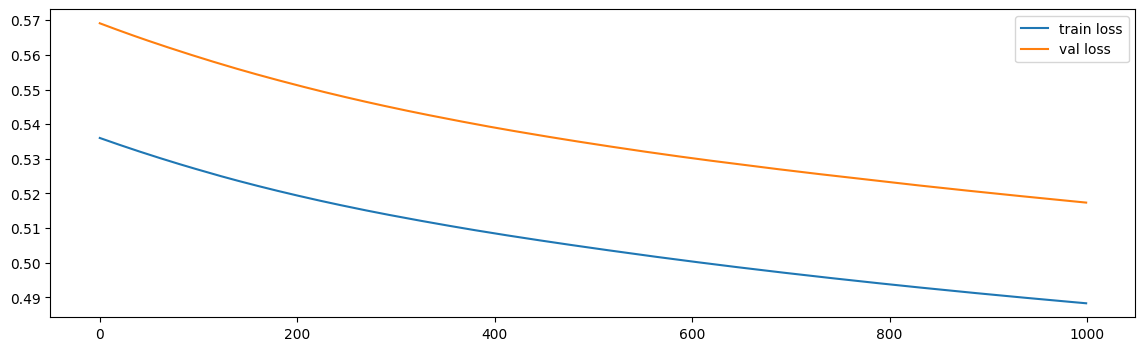

In [15]:
plt.figure(figsize=(14,4))
plt.plot(train_loss_hist, label='train loss')
plt.plot(val_loss_hist, label='val loss')

plt.legend()
plt.show()